# NLP Word Embeddings



## Introduction
In the previous notebook, we learned how to tokenize text and convert tokens into numerical IDs. However, these IDs alone aren't very useful for understanding language. For example, if "dog" is ID 582 and "cat" is ID 267, these numbers don't tell us anything about the relationship between these words. The IDs are arbitrary labels that don't capture meaning or similarity.

This is where **word embeddings** come in. Word embeddings are a way to represent words as vectors of real numbers in a continuous space, where the relationships between the vectors reflect meaningful relationships between the words. For instance, similar words should be close to each other in this space, and the directions between words can capture meaningful relationships.

For simplicity, in the following examples, we'll work with whole words rather than tokens, but the same principles apply to token embeddings used in models like BERT.

Part of this notebook has been inspired from Jay Alammar's blog post [The Illustrated Word2Vec](https://jalammar.github.io/illustrated-word2vec/).

## Required installations

In [ ]:
# We import some basic libraries for some operations later in the notebook

!pip install -q gensim scikit-learn matplotlib seaborn

import gensim.downloader as api
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Understanding Word Embeddings

Imagine we want to represent the meaning of words on a simple scale. Let's take the concept of **size**: we could rate words on a scale from -1 to 1, where -1 represents "very small" and 1 represents "very large". The word "tiny" might score -0.9, "mouse" might be -0.5, "dog" could be 0.2, and "elephant" might score 0.8. This single number tells us something about each word's meaning in terms of size.

Now, let's add a second dimension: **speed**. We could rate the same words on a scale from -1 (very slow) to 1 (very fast). Now each word has two numbers describing it: one for size and one for speed. For example:
- "elephant": (0.9, 0.2) - large and medium pace
- "snail": (-0.7, -0.8) - small and slow
- "cheetah": (0.3, 0.9) - medium-sized but fast
- "hummingbird": (-0.7, 0.8) - small and fast

<br>

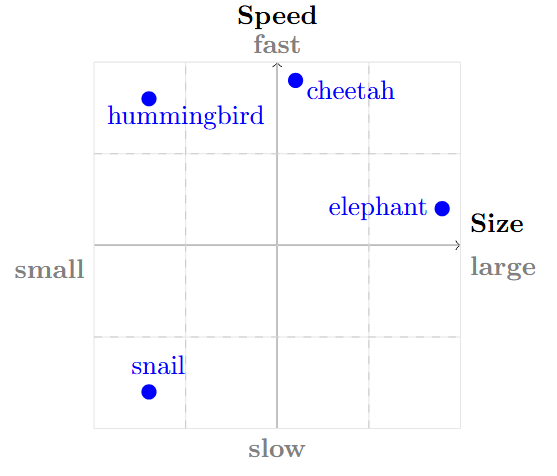

This two-dimensional representation already gives us more information about each word than a single dimension could. We can now see that while a snail and a hummingbird are similar in size, they're very different in speed. A cheetah and a hummingbird might be quite different in size, but they're both quite fast, when it comes to the animal kingdom

The number of dimensions equals the number of properties we want to capture about each word. To measure similarity between these word vectors, we use [Cosine Similarity](https://en.wikipedia.org/wiki/Cosine_similarity), which measures the angle between two vectors regardless of their magnitude:

$\text{cosine_similarity}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{|\mathbf{a}| |\mathbf{b}|} = \frac{\sum_{i=1}^{n} a_i b_i}{\sqrt{\sum_{i=1}^{n} a_i^2} \sqrt{\sum_{i=1}^{n} b_i^2}}$

Where:
- $\mathbf{a}$ and $\mathbf{b}$ are word vectors of dimension $n$
- $a_i$ and $b_i$ are the values in dimension $i$ for each vector
- $\mathbf{a} \cdot \mathbf{b}$ is the dot product of the vectors
- $|\mathbf{a}|$ and $|\mathbf{b}|$ are the magnitudes (lengths) of the vectors
- $n$ is the number of dimensions (50 in our GloVe embeddings)

This measure:
- Ranges from -1 (completely opposite) to 1 (identical direction)
- Focuses on the angle between vectors, not their magnitude
- Works well in high-dimensional spaces

For example, we might find that "cheetah" and "lion" have a high cosine similarity (close to 1) as they share many properties - both are medium-sized, fast predators. In contrast, their similarity with "elephant" would be lower, reflecting the greater semantic distance between these concepts.

In real word embeddings, we use hundreds or thousands of dimensions to capture many subtle aspects of meaning. These dimensions might represent concepts like:
- Temperature (cold vs. hot)
- Weight (light vs. heavy)
- Color (dark vs. light)
- Abstractness (concrete vs. abstract)
- Sentiment (negative vs. positive)
And many others that together create a rich representation of each word's meaning.

### So far, we have come up with two key ideas:
1. We can represent words as vectors of numbers, which is crucial for machine learning models to process. Instead of treating words as arbitrary symbols, we can represent them as points in a continuous space where their positions carry meaning.
2. We can easily calculate the similarity between words by comparing their vectors. Words that are used in similar contexts or have similar meanings will have similar vectors, allowing us to mathematically measure how related words are.

This is why embeddings are so powerful: they transform words from simple symbols into rich, meaningful representations that capture the complex relationships between words in our language.

## Practical approach to word embedding

### Working with Pre-trained Word Embeddings

Language models like BERT and GPT learn their own embeddings during training, a process that requires massive amounts of data and computational resources. Here, we we will use simpler pre-trained word embeddings, like the `glove-wiki-gigaword-50` model.

#### What is GloVe Wiki-Gigaword?
- **GloVe** (Global Vectors for Word Representation) is a [technique developed by Stanford](https://aclanthology.org/D14-1162.pdf) that creates word embeddings by analyzing how often words appear together
- The model is trained on a combination of Wikipedia articles and news archives (Gigaword corpus)
- Each word is represented by a 50-dimensional vector (hence `glove-wiki-gigaword-50`)

These embeddings enable various NLP tasks:
- Finding similar words by comparing vector distances
- Text classification using vector representations
- Semantic analysis and topic modeling

In the following sections, we'll load and explore this model using the `Gensim` library.

In [ ]:
model = api.load('glove-wiki-gigaword-50')  # This might take a while

Let's look for the word 'king' in our model.

In [ ]:
print(f"The vector 'king' has: {len(model['king'])} pair of traits")
print(f"The vector which corresponds to the word 'king' is: \n{model['king']}")

The vector 'king' has: 50 pair of traits
The vector which corresponds to the word 'king' is: 
[ 0.50451   0.68607  -0.59517  -0.022801  0.60046  -0.13498  -0.08813
  0.47377  -0.61798  -0.31012  -0.076666  1.493    -0.034189 -0.98173
  0.68229   0.81722  -0.51874  -0.31503  -0.55809   0.66421   0.1961
 -0.13495  -0.11476  -0.30344   0.41177  -2.223    -1.0756   -1.0783
 -0.34354   0.33505   1.9927   -0.04234  -0.64319   0.71125   0.49159
  0.16754   0.34344  -0.25663  -0.8523    0.1661    0.40102   1.1685
 -1.0137   -0.21585  -0.15155   0.78321  -0.91241  -1.6106   -0.64426
 -0.51042 ]


Now we see that the word king is associated with 50 pair of traits. Let's try to visualize and color code each cell based on its value.

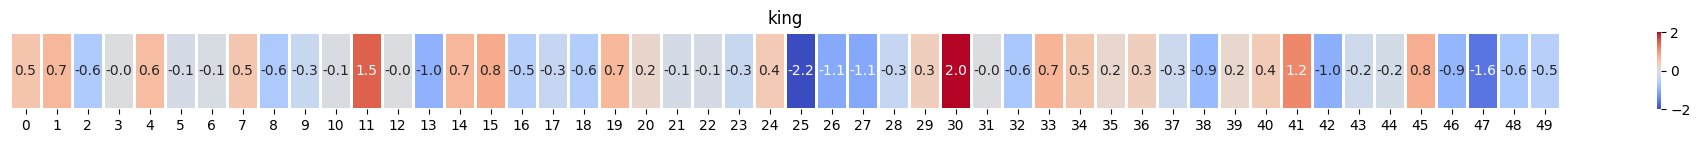

In [ ]:
plt.figure(figsize=(25,1))
sns.heatmap([model["king"]], xticklabels=True, yticklabels=False, cbar=True, vmin=-2, vmax=2, linewidths=0.85, cmap='coolwarm', annot=True, fmt=".1f")
plt.title('king')
plt.show()


We’ll proceed by ignoring the numbers and only looking at the colors to indicate the values of the cells. Let’s now contrast “King” against other words:

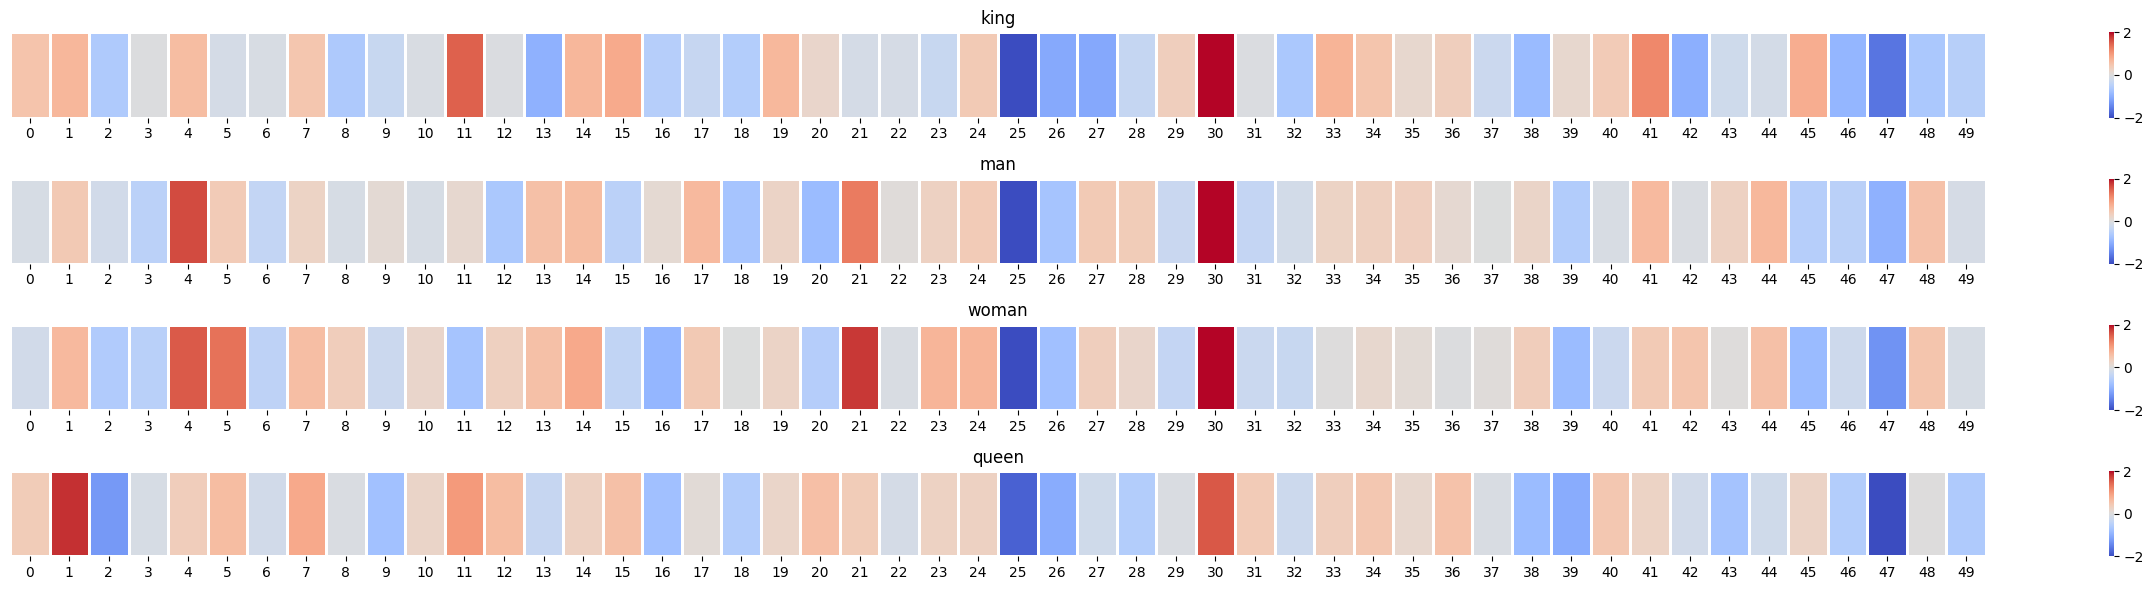

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(25, 6))

sns.heatmap([model["king"]], ax=axes[0], xticklabels=True, yticklabels=False, cbar=True, vmin=-2, vmax=2, linewidths=0.85, cmap='coolwarm')
axes[0].set_title('king')

sns.heatmap([model["man"]], ax=axes[1], xticklabels=True, yticklabels=False, cbar=True, vmin=-2, vmax=2, linewidths=0.85, cmap='coolwarm')
axes[1].set_title('man')

sns.heatmap([model["woman"]], ax=axes[2], xticklabels=True, yticklabels=False, cbar=True, vmin=-2, vmax=2, linewidths=0.85, cmap='coolwarm')
axes[2].set_title('woman')

sns.heatmap([model["queen"]], ax=axes[3], xticklabels=True, yticklabels=False, cbar=True, vmin=-2, vmax=2, linewidths=0.85, cmap='coolwarm')
axes[3].set_title('queen')

plt.tight_layout()
plt.show()

See how “Man” and “Woman” are more similar to each other than either of them is to “king”? This tells you something. These vector representations capture quite a bit of the information/meaning/associations of these words. Similarly, "King" and "Queen" appear more similar, check for instance the colors at dimension 11, 21, or 47.

These visualizations demonstrate how word embeddings may capture multiple aspects of meaning:
- Semantic relationships (royalty, gender)
- Word associations
- Hierarchical relationships

Each dimension potentially represents a different semantic feature, and the combination of these features creates a rich representation of word meaning.

Here’s another list of examples (compare by vertically scanning the columns looking for columns with similar colors):

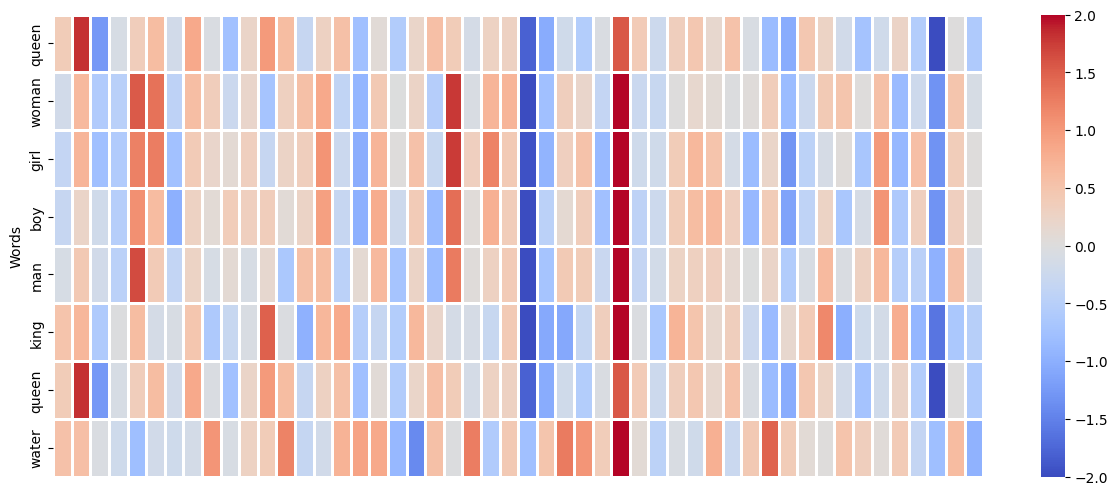

In [ ]:
y_labels = ['queen', 'woman', 'girl', 'boy', 'man', 'king', 'queen', 'water']

plt.figure(figsize=(15, 6))
sns.heatmap([model["queen"],
             model["woman"],
             model["girl"],
             model["boy"],
             model["man"],
             model["king"],
             model["queen"],
             model["water"],
            ],
            cbar=True,
            xticklabels=False,
            yticklabels=y_labels,
            vmin=-2,
            vmax=2,
            cmap='coolwarm',
            linewidths=1)
plt.ylabel('Words')
plt.show()

Some key Observations:

1. **Shared Dimensions**
   Notice the consistent red column across different words, indicating a dimension where these words share similar values. While we can't definitively say what each dimension represents, these patterns reveal shared semantic properties.

2. **Gender and Age Relationships**
   "Woman" and "girl" show similar patterns across multiple dimensions, as do "man" and "boy". This suggests these embeddings capture both gender and age-related semantic features.

3. **Age-Specific Features**
   Interestingly, "boy" and "girl" share patterns that differ from both "woman" and "man", potentially capturing age-related semantic properties. These shared features might represent concepts related to youth or childhood.

4. **Category Distinctions**
   Most words here represent people, except "water". Notice how certain patterns (like the blue column) appear consistently across the person-related words but change dramatically for "water", demonstrating how embeddings capture fundamental categorical differences.

These patterns reveal how word embeddings capture multiple layers of meaning: from basic categories to nuanced social and demographic concepts.

### Vector Arithmetic in Word Embeddings

A fundamental property of word embeddings is their ability to capture semantic relationships through vector arithmetic. Since words are represented as numerical vectors, we can perform mathematical operations that reveal semantic relationships.

The canonical example is:

$\text{King} - \text{Man} + \text{Woman} = \text{Queen}$

This equation demonstrates that the vector difference between "King" and "Man" captures a relationship that, when applied to "Woman", approximates the vector for "Queen". Similar arithmetic operations may work for various semantic relationships:

- Geographic: $\text{Paris} - \text{France} + \text{Italy} \approx \text{Rome}$
- Verb tense: $\text{walking} - \text{walking} + \text{run} \approx \text{running}$
- Comparative: $\text{good} - \text{better} + \text{bad} \approx \text{worse}$

These arithmetic properties indicate that word embeddings encode systematic semantic relationships in their vector space.

Let's see if the geographic example mention before works!

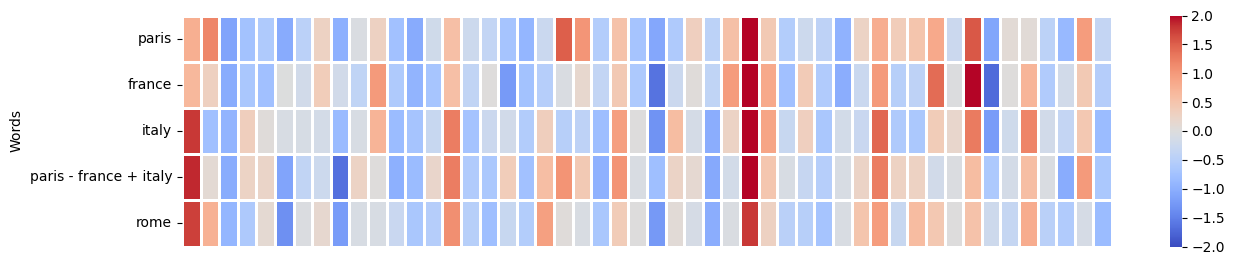

In [ ]:
y_labels = ['paris', 'france', 'italy', 'paris - france + italy', 'rome']
plt.figure(figsize=(15, 3))
sns.heatmap([model["paris"],
             model["france"],
             model["italy"],
             model["paris"] - model["france"] + model["italy"],
             model["rome"],
            ],
            cbar=True,
            xticklabels=False,
            yticklabels=y_labels,
            vmin=-2,
            vmax=2,
            cmap='coolwarm',
            linewidths=1)
plt.ylabel('Words')
plt.show()

Looking at the computed vector ("paris - france + italy") and the actual vector for "rome", we see remarkably similar color patterns across most dimensions.

This geographic transformation works particularly well because the relationship between Paris and France is semantically very similar to the relationship between Rome and Italy - both capture the concept of "capital city of". The matching patterns in the heatmap demonstrate how the embedding space has learned to encode these geographic relationships systematically.

While GloVe embeddings were trained simply on word co-occurrence statistics, they've captured complex real-world relationships. When we compute the closest words to our "paris - france + italy" vector among the 400,000 words in the vocabulary, "rome" emerges at the top, confirming that these embeddings have learned meaningful geographic relationships through the statistical patterns in language.

In [ ]:
# Find closest words
closest_words = model.most_similar(model["paris"] - model["france"] + model["italy"], topn=5)

# Display results
for word, similarity in closest_words:
    print(f"{word}: {similarity:.4f}")

rome: 0.8379
italy: 0.7875
milan: 0.7715
turin: 0.7603
venice: 0.7575


Gensim's `most_similar()` method implements cosine similarity by default, we can easily compute it ourselves to understand what's happening under the hood.


In [ ]:
def cosine_similarity(v1, v2):
    """
    Compute cosine similarity between two vectors.
    """
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    return dot_product / (norm_v1 * norm_v2)

# Compute target vector
target_vector = model["paris"] - model["france"] + model["italy"]

# List of Italian cities to compare with
italian_cities = ["rome", "italy", "milan", "turin", "venice"]

# Compute similarities
similarities = []
for city in italian_cities:
    vec = model[city]
    sim = cosine_similarity(target_vector, vec)
    similarities.append((city, sim))

# Sort by similarity
closest_words = sorted(similarities, key=lambda x: x[1], reverse=True)

# Display results
for word, sim in closest_words:
    print(f"{word}: {sim:.4f}")

rome: 0.8379
italy: 0.7875
milan: 0.7715
turin: 0.7603
venice: 0.7575


### Visualizing Embeddings in 2D using PCA

To visualize these 50-dimensional word vectors, we need to reduce their dimensionality. We'll use Principal Component Analysis (PCA), a technique you've encountered before. As a quick recap, PCA finds the directions (principal components) in the data that:
- Capture the maximum variance
- Are orthogonal to each other
- Allow dimensionality reduction while minimizing information loss

In our case, PCA will project our 50-dimensional word vectors onto a 2D space, keeping the two directions that best preserve the relationships between words. While this projection necessarily loses some information, it maintains the most significant patterns in the data, making it ideal for visualization.

For a detailed refresher on PCA, see the [Wikipedia article](https://en.wikipedia.org/wiki/Principal_component_analysis).

In [ ]:
# Select words to visualize
words = ['king', 'man', 'woman', 'queen', 'apple', 'orange', 'banana', 'fruit',
         'dog', 'cat', 'horse','animal', 'river','mountain','lake','landscape']

# Get word vectors
word_vectors = np.array([model[word] for word in words])
pca = PCA(n_components = 2)
word_vectors_2d = pca.fit_transform(word_vectors)

Let’s plot the reduced 2D word vectors to visualize their relationships. Each word will appear as a labeled point in the 2D space, allowing us to observe semantic groupings and similarities.

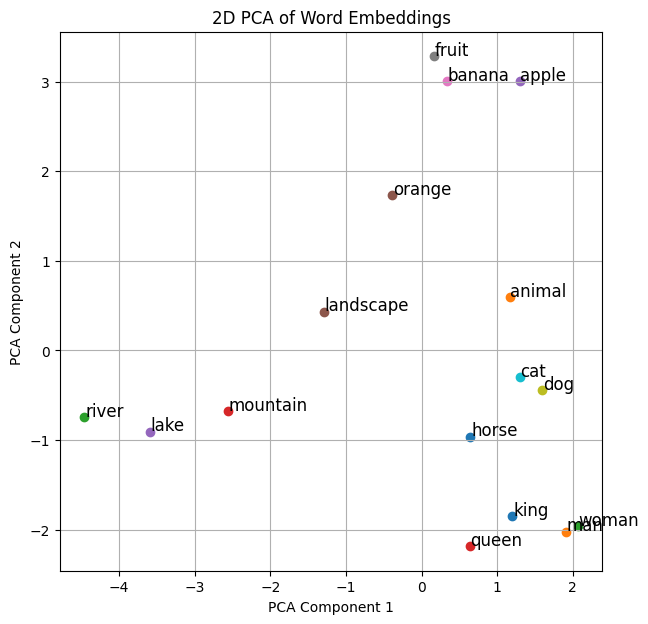

In [ ]:
plt.figure(figsize=(7, 7))
for i, word in enumerate(words):
    plt.scatter(word_vectors_2d[i, 0], word_vectors_2d[i, 1])
    plt.text(word_vectors_2d[i, 0] + 0.01, word_vectors_2d[i, 1] + 0.01, word, fontsize=12)

plt.title('2D PCA of Word Embeddings')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

### Exercise: Word Vector Algebra

In this exercise, you'll explore how to perform word vector algebra.
We'll work with the analogy:
$\text{Paris} - \text{France} + \text{Germany} \approx \text{Berlin}$

Your tasks:
1. Extract word vectors for 'paris', 'france', 'germany', and 'berlin'
2. Compute the vector arithmetic: paris - france + germany
3. Calculate the cosine similarity between your result and the vector for 'berlin'
4. Visualize all vectors in 2D space using PCA

This will demonstrate how embeddings capture the relationship "X is the capital of Y" and how we can use vector arithmetic to find analogous relationships.

In [ ]:
def get_word_vectors(words, model):
    """
    Get word vectors from model and store in dictionary
    """
    vectors = {}
    for word in words:
        vectors[word] = model[word]
    return vectors

def compute_analogy(word1, word2, word3, vectors):
    """
    Compute word1 - word2 + word3
    """
    return vectors[word1] - vectors[word2] + vectors[word3]

def plot_word_vectors(words, vectors, result_vector, title="Vector Algebra in 2D PCA Space"):
    """
    Plot word vectors and result in 2D PCA space
    """
    # Prepare vectors for PCA
    word_vectors = np.array(list(vectors.values()))

    # Apply PCA
    pca = PCA(n_components=2)
    word_vectors_2d = pca.fit_transform(np.vstack([word_vectors, result_vector]))

    # Plot
    plt.figure(figsize=(5, 5))

    # Plot original words
    for i, word in enumerate(words):
        plt.scatter(word_vectors_2d[i, 0], word_vectors_2d[i, 1])
        plt.text(word_vectors_2d[i, 0] + 0.01, word_vectors_2d[i, 1] + 0.01,
                word, fontsize=12)

    # Plot result vector
    result_idx = len(words)
    plt.scatter(word_vectors_2d[result_idx, 0], word_vectors_2d[result_idx, 1],
               color='red', label='Result Vector')
    plt.text(word_vectors_2d[result_idx, 0] + 0.01, word_vectors_2d[result_idx, 1] + 0.01,
            'Result Vector', fontsize=12, color='red')

    plt.title(title)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.grid(True)
    plt.show()

Cosine similarity with 'berlin': 0.9181


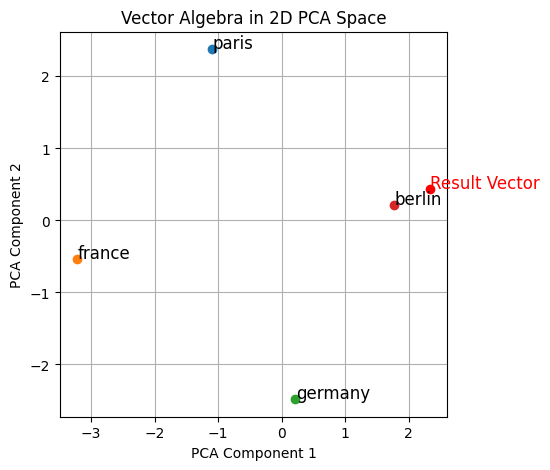

In [ ]:
# Example usage:
words = ['paris', 'france', 'germany', 'berlin']
vectors = get_word_vectors(words, model)
result_vector = compute_analogy('paris', 'france', 'germany', vectors)

# Compare with target word (berlin)
similarity = cosine_similarity(result_vector, vectors['berlin'])
print(f"Cosine similarity with 'berlin': {similarity:.4f}")

# Visualize
plot_word_vectors(words, vectors, result_vector)

To further explore the capabilities of word embeddings, you can experiment with different analogies. Some examples you can look at can be:

- The other examples encountered before (i.e., other cities, king & queens)
- $\text{Cat} - \text{Singular} + \text{Plural} = \text{Cats}$ (Relationship between singular and plural forms of a noun)
- $\text{Doctor} - \text{Male} + \text{Female} = \text{Nurse}$ (Potential biases in machine learning models)

Capitals: Cosine similarity with 'rome': 0.8379


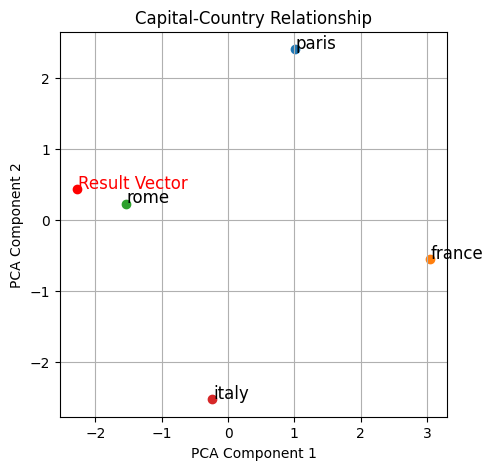

Singular-Plural: Cosine similarity with 'cats': 0.8995


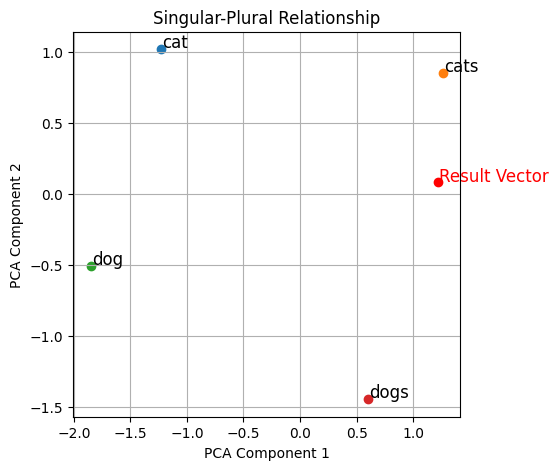

Gender-Royal: Cosine similarity with 'queen': 0.8610


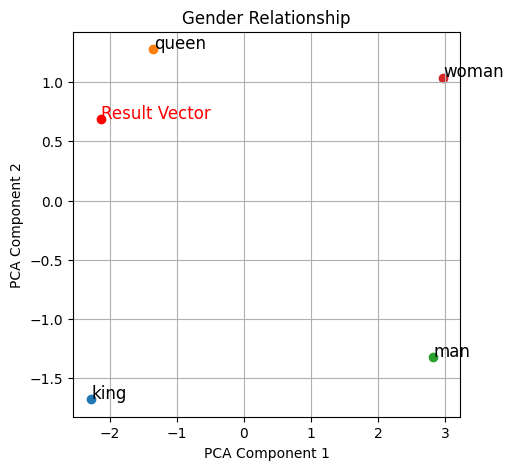

Gender-Occupation: Cosine similarity with 'nurse': 0.8424


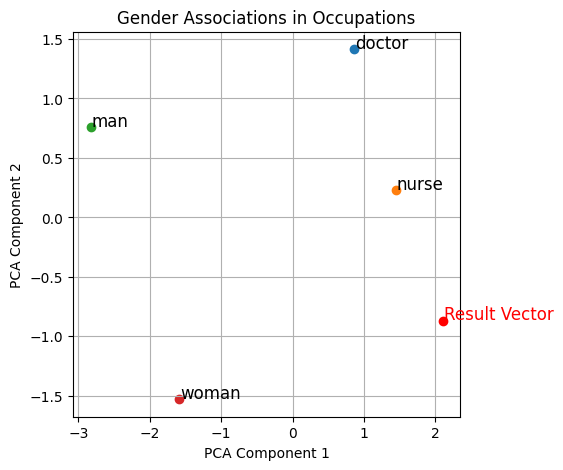

In [ ]:
# Define all examples
analogies = [
    {
        'words': ['paris', 'france', 'rome', 'italy'],
        'analogy': ('paris', 'france', 'italy', 'rome'),
        'title': "Capital-Country Relationship",
        'type': "Capitals"
    },
    {
        'words': ['cat', 'cats', 'dog', 'dogs'],
        'analogy': ('cat', 'dog', 'dogs', 'cats'),
        'title': "Singular-Plural Relationship",
        'type': "Singular-Plural"
    },
    {
        'words': ['king', 'queen', 'man', 'woman'],
        'analogy': ('king', 'man', 'woman', 'queen'),
        'title': "Gender Relationship",
        'type': "Gender-Royal"
    },
    {
        'words': ['doctor', 'nurse', 'man', 'woman'],
        'analogy': ('doctor', 'man', 'woman', 'nurse'),
        'title': "Gender Associations in Occupations",
        'type': "Gender-Occupation"
    }
]

# Process each analogy
for example in analogies:
    vectors = get_word_vectors(example['words'], model)
    w1, w2, w3, target = example['analogy']
    result_vector = compute_analogy(w1, w2, w3, vectors)

    similarity = cosine_similarity(result_vector, vectors[target])
    print(f"{example['type']}: Cosine similarity with '{target}': {similarity:.4f}")

    plot_word_vectors(example['words'], vectors, result_vector, example['title'])